# Model Pipeline
This notebook implements the complete forecasting workflow, structured into four main stages:

1. **Feature Engineering:** Operational lagging and non-linear transformations.
2. **Machine Learning & Deep Learning:** Parallel evaluation of Gradient Boosting (XGBoost, LightGBM) and Neural Networks (N-HiTS, LSTM).
3. **Ensemble Modeling:** Strategic combination of top-performing models to reduce residual variance.
4. **Error Analysis:** Detailed diagnostic of residuals to identify systematic biases.

## 1. Load, Clean & Feature Engineering

We execute the cleaning and feature construction suite in two sequential steps.

1. First, the raw 29-column dataset is filtered down to four core variables: `total load actual`, `price day ahead`, `price actual`, and `temp_national`.

2. From these, the pipeline constructs 22 features — including lag/rolling signals, weather derivatives (HDH, CDH), cyclical calendar encodings, holiday flags, and astronomical variables. Rows lost to lag initialisation are dropped, yielding a final matrix of **34,873 × 22**.

In [8]:
from feature_engineering import load_and_clean_data, engineer_features

df_clean = load_and_clean_data(
    dataset_path="data/df_clean.csv",
)
df_model = engineer_features(df_clean)

print("--- SAMPLE OUTPUT ---")
display(df_model.head())

--- 1. LOADING AND FILTERING DATA ---
ORIGINAL COLUMNS:['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind onshore', 'total load actual', 'price day ahead', 'price actual', 'temp_national', 'temp_min_national', 'temp_max_national', 'pressure_national', 'humidity_national', 'wind_speed_national', 'wind_deg_national', 'rain_1h_national', 'snow_3h_national', 'clouds_all_national', 'weather_id_national']
Data loading complete. Retained columns: ['total load actual', 'price day ahead', 'price actual', 'temp_national']

--- 2. FEATURE ENGINEERING ---
Generating system memory features (lags & rolling)...
Building smart weather features (HDH,

,total load actual,temp_national,lag_price_24,load_lag_24,load_lag_168,load_rolling_mean_7d,load_rolling_mean_24h,load_std_24h,load_diff_24h,HDH,...,day_of_week,hour_sin,hour_cos,month_sin,month_cos,is_holiday,next_day_is_holiday,is_bridge_day,day_length_h,is_daylight
time,,,,,,,,,,,,,,,,,,,,,
2015-01-08 22:00:00+00:00,26436.0,1.99686,75.07,30477.0,26798.0,26569.744048,32105.000000,3750.439313,3056.0,13.00314,...,3,-0.500000,0.866025,0.5,0.866025,0,0,0,9.433333,0
2015-01-08 23:00:00+00:00,27485.0,2.01451,73.73,26788.0,27070.0,26578.095238,31949.583333,3893.615185,-3730.0,12.98549,...,3,-0.258819,0.965926,0.5,0.866025,0,0,0,9.450000,0
2015-01-09 00:00:00+00:00,25750.0,1.83200,70.99,25146.0,24935.0,26582.642857,31810.500000,4078.041516,-3338.0,13.16800,...,4,0.000000,1.000000,0.5,0.866025,0,0,0,9.450000,0
2015-01-09 01:00:00+00:00,24760.0,1.68315,68.30,23889.0,23214.0,26589.517857,31679.791667,4283.174412,-3137.0,13.31685,...,4,0.258819,0.965926,0.5,0.866025,0,0,0,9.450000,0
2015-01-09 02:00:00+00:00,24188.0,1.90336,64.22,23046.0,22540.0,26599.994048,31546.375000,4503.907519,-3202.0,13.09664,...,4,0.500000,0.866025,0.5,0.866025,0,0,0,9.450000,0


Before modelling, we inspect the linear relationships between the engineered features and the target variable. The heatmap below reveals inter-feature dependencies and potential multicollinearity, while the ranking table identifies the strongest individual predictors of `total load actual`.

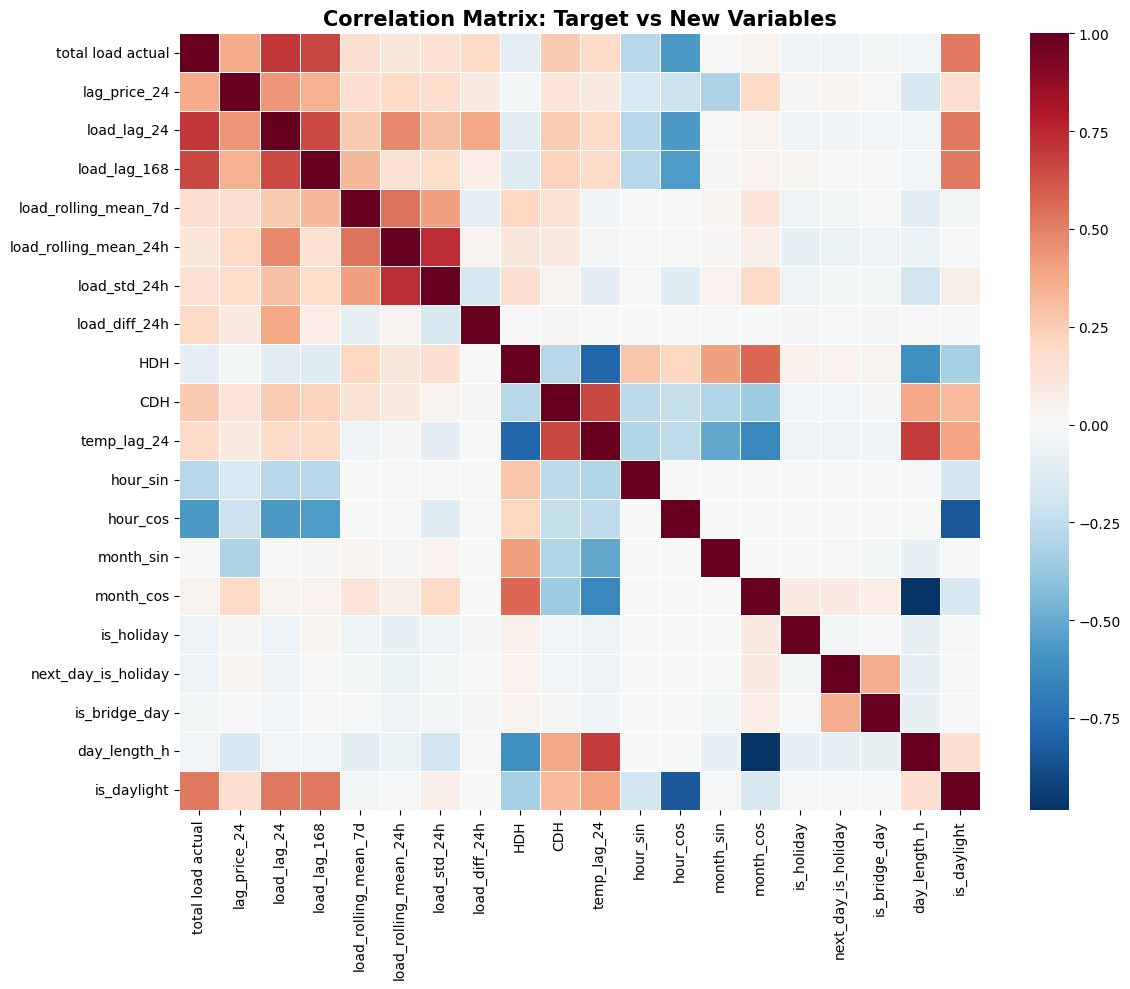

--- Ranking de Correlación con 'total load actual' ---
                       total load actual
total load actual               1.000000
load_lag_24                     0.703438
load_lag_168                    0.660911
is_daylight                     0.520041
lag_price_24                    0.369173
CDH                             0.260552
load_diff_24h                   0.197254
temp_lag_24                     0.189089
load_rolling_mean_7d            0.169915
load_std_24h                    0.148817
load_rolling_mean_24h           0.116932
month_cos                       0.035737
month_sin                       0.007141
is_bridge_day                  -0.023952
day_length_h                   -0.034241
next_day_is_holiday            -0.055187
is_holiday                     -0.059036
HDH                            -0.100496
hour_sin                       -0.277565
hour_cos                       -0.565752


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

new_features = [
    'total load actual',
    'lag_price_24',
    'load_lag_24', 'load_lag_168',
    'load_rolling_mean_7d', 'load_rolling_mean_24h',
    'load_std_24h', 'load_diff_24h',
    'HDH', 'CDH', 'temp_lag_24',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_holiday', 'next_day_is_holiday', 'is_bridge_day',
    'day_length_h', 'is_daylight'
]

existing_features = [f for f in new_features if f in df_model.columns]

corr_matrix = df_model[existing_features].corr()

target_corr = corr_matrix[['total load actual']].sort_values(by='total load actual', ascending=False)

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=False,
            cmap='RdBu_r', 
            center=0,
            linewidths=0.5)

plt.title("Correlation Matrix: Target vs New Variables", fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

print("--- Ranking de Correlación con 'total load actual' ---")
print(target_corr)

The correlation ranking reveals several critical insights into the demand drivers:

* **Temporal Persistence:** `load_lag_24` (0.70) and `load_lag_168` (0.66) are the strongest predictors, confirming the highly periodic nature of the Spanish grid.
* **Solar & Human Activity:** The `is_daylight` flag (0.52) and `hour_cos` (-0.56) show high absolute correlations, effectively acting as proxies for active hours and lighting demand.
* **Thermal Response:** Cooling Degree Hours (`CDH`: 0.26) show a stronger linear relationship than Heating Degree Hours (`HDH`: -0.10), suggesting that summer demand peaks are more sensitive to extreme temperature shifts in this dataset.
* **Behavioral Indicators:** Operational flags like `is_holiday` and `is_bridge_day` show lower linear correlation coefficients. However, these are retained as they serve as critical "variance triggers" for non-linear models during anomalous days.

## 2. Train / Test Split & TSO Baseline

We split the dataset temporally at **2018-01-01**, reserving all prior data for training and the remaining period for evaluation. No shuffling is applied to preserve the time series structure.

As a reference benchmark, we evaluate the **TSO baseline** (the official day-ahead load forecast published by the system operator). All subsequent models are assessed against this baseline to quantify the added value of the ML pipeline

Splitting data at cutoff date: 2018-01-01 00:00:00+00:00
  Training set: 26,114 hours (2015-01-08 to 2017-12-31)
  Testing set:  8,759 hours (2018-01-01 to 2018-12-31)

Calculating official TSO baseline metrics...
OFFICIAL TSO BASELINE (2018):
   MAE:  269.85 MWh
   MAPE: 0.926 %
   RMSE: 389.32 MWh


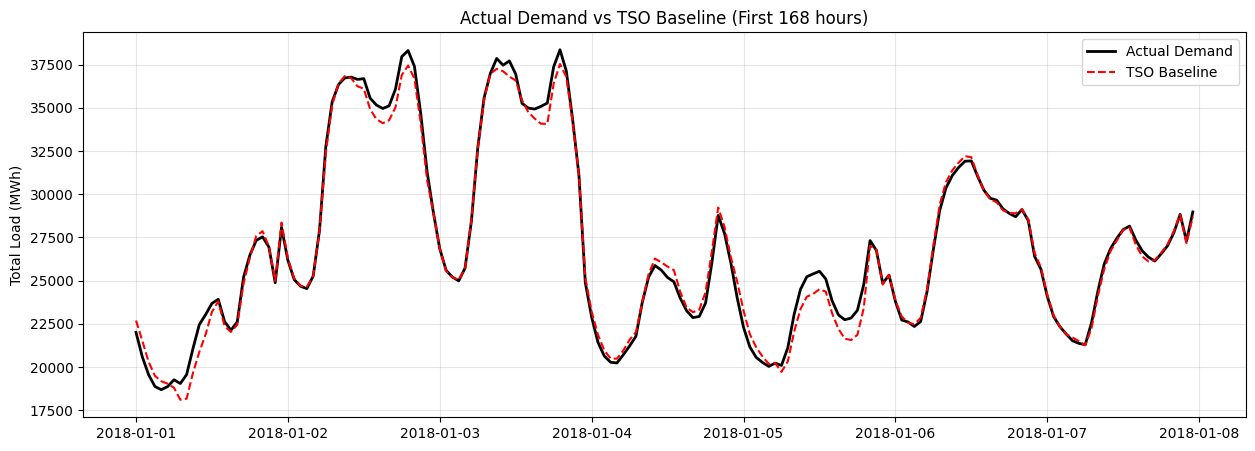

In [10]:
from evaluate import temporal_train_test_split, evaluate_tso_baseline, plot_forecast_vs_actual

X_train, X_test, y_train, y_test = temporal_train_test_split(
    df=df_model,
    target_col="total load actual",
    cutoff_date="2018-01-01 00:00:00+00:00",
)

tso_forecast, tso_metrics = evaluate_tso_baseline(
    y_test=y_test,
    energy_csv_path="data/energy_dataset.csv",
)

plot_forecast_vs_actual(y_actual=y_test, y_pred=tso_forecast,
                        model_name="TSO Baseline", window_hours=168)

The TSO baseline achieves a **MAE of 269.85 MWh** and **MAPE of 0.926%** over the 2018 test period, a strong reference reflecting years of operational refinement. The plot confirms good general tracking of daily and weekly patterns, though visible phase shifts and amplitude errors at demand troughs and peaks leave room for improvement.

## 3. XGBoost

We train an XGBoost regressor with randomised cross-validation search over key hyperparameters. Performance is evaluated against the test set and benchmarked directly against the TSO baseline. Feature importances are plotted for the top 20 predictors.


--- XGBoost: TIME SERIES CV HYPERPARAMETER SEARCH ---
Running 10 random combinations × 5 folds …
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Cross-validation complete.
Best params:
  subsample: 0.9
  n_estimators: 1500
  min_child_weight: 3
  max_depth: 10
  learning_rate: 0.01
  colsample_bytree: 0.8
CV MAE (best): 1,673.00 MWh

XGBoost — TEST SET 2018
  MAE  : 1,499.52 MWh  (▲1,229.67 vs TSO)
  MAPE : 5.137 %
  RMSE : 2,312.00 MWh


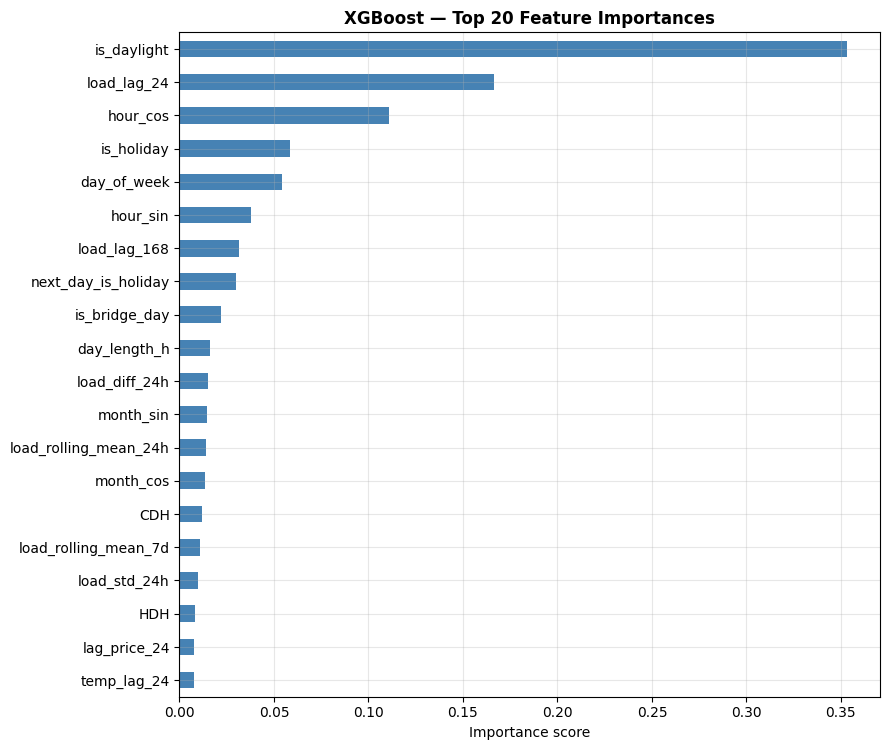

In [11]:
from modeling_ml import tune_xgboost_with_cv, evaluate_xgboost, plot_xgb_feature_importance

best_xgb = tune_xgboost_with_cv(X_train, y_train, n_iter=10)
xgb_preds, xgb_metrics = evaluate_xgboost(best_xgb, X_test, y_test, tso_metrics=tso_metrics)
plot_xgb_feature_importance(best_xgb, X_train, top_n=20)

XGBoost achieves a **MAE of 1,499 MWh** and **MAPE of 5.14%** on the 2018 test set, significantly below the TSO baseline, indicating that the model struggles to match operational forecast quality with the current feature set. The feature importance chart reveals that temporal and astronomical signals (`is_daylight`, `hour_cos`, `hour_sin`) dominate, while the 24-hour load lag (`load_lag_24`) is the strongest memory feature. Weather derivatives (HDH, CDH) and price lags contribute marginally.

## 4. LightGBM (Probabilistic)

We train a LightGBM ensemble across three quantiles (10th, 50th, 90th percentile) to produce point forecasts alongside calibrated prediction intervals. Coverage is evaluated against an 80% target, and feature importances are extracted from the median model.



--- LightGBM: QUANTILE REGRESSION ---
Training median model (α=0.50)…
Training lower bound  (α=0.10)…
Training upper bound  (α=0.90)…

📊 LightGBM Median — TEST SET 2018
  MAE  : 1,485.13 MWh  (▲1,215.28 vs TSO)
  MAPE : 5.079 %
  RMSE : 2,339.57 MWh

--- INTERVAL METRICS ---
  Target coverage : 80%
  PICP            : 53.47%  ⚠️  below target
  MPIW            : 2,651.47 MWh
  Winkler score   : 8,319.38 MWh  (lower = better)


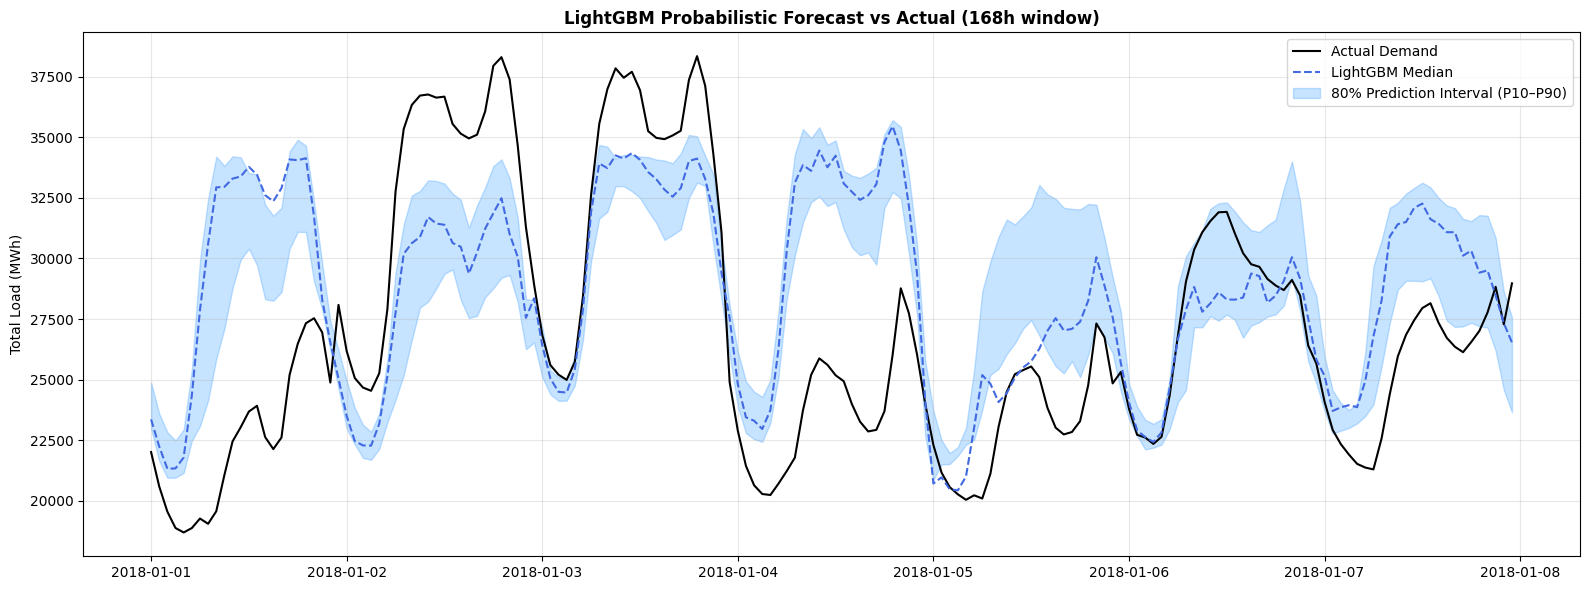

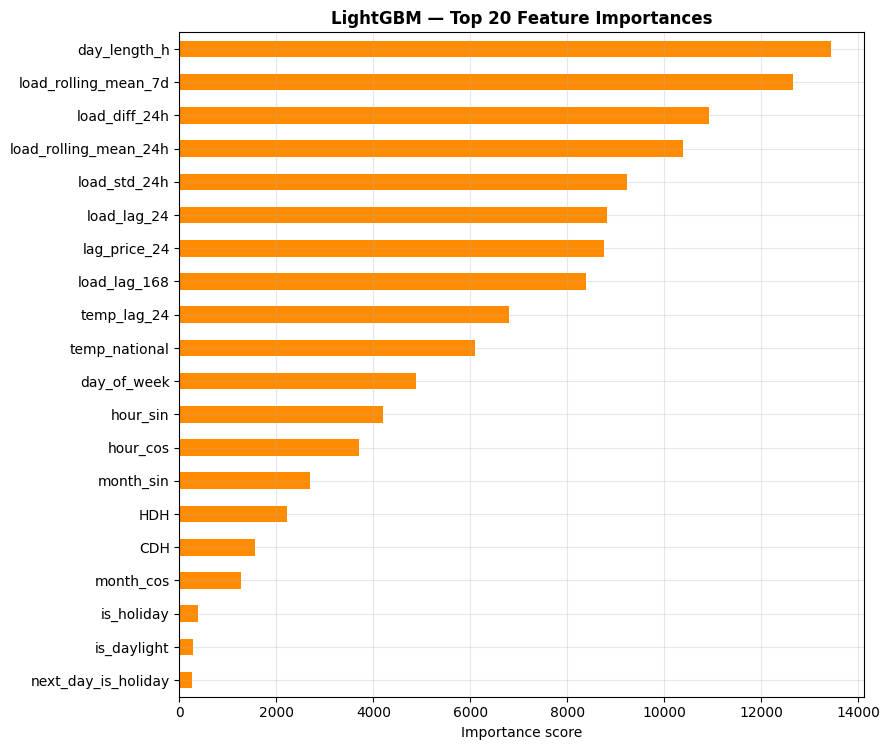

In [12]:
from modeling_ml import (
    train_and_evaluate_lgbm_quantiles,
    evaluate_prediction_intervals,
    plot_lightgbm_intervals,
    plot_lgbm_feature_importance,
)

df_quantiles, best_lgbm, lgbm_metrics = train_and_evaluate_lgbm_quantiles(
    X_train, y_train, X_test, y_test, tso_metrics=tso_metrics,
)

interval_metrics = evaluate_prediction_intervals(df_quantiles, target_coverage=0.80)

plot_lightgbm_intervals(df_quantiles, window_hours=168, start_idx=0)
plot_lgbm_feature_importance(best_lgbm, X_train, top_n=20)

## 5. Alternative Models (CatBoost / MLP / Random Forest)

In [13]:
from modeling_ml import train_alternative_models

alt_preds, alt_metrics = train_alternative_models(
    X_train, y_train, X_test, y_test, tso_metrics=tso_metrics,
)


--- ALTERNATIVE MODELS ---
Training CatBoost…
Training MLP (Neural Network)…
Training Random Forest…

ALTERNATIVE MODELS — TEST SET 2018
Model          |        MAE |  MAPE (%) |       RMSE
----------------------------------------------------
TSO (goal)     |     269.85 |     0.926 |     389.32  ← baseline
----------------------------------------------------
CatBoost       |    1488.35 |     5.080 |    2278.51
MLP            |    1870.69 |     6.469 |    2568.02
RandomForest   |    1584.77 |     5.458 |    2395.38


## 6. Deep Learning Fleet

In [14]:
from modeling_dl import prepare_darts_from_split, train_and_evaluate_deep_learning_fleet

darts_dataset = prepare_darts_from_split(X_train, y_train, X_test, y_test)

predictions, leaderboard = train_and_evaluate_deep_learning_fleet(
    darts_dataset,
    lookback_hours=168,
    horizon=24,
    max_epochs=60,
    tso_metrics=tso_metrics,   # live TSO comparison in leaderboard
)

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


--- 1. PREPARING DARTS DATA FROM EXISTING TRAIN/TEST SPLIT ---
  Future covariates : 10 columns (Calendario + Solar)
  Past covariates   : 5 columns (Clima real)
  Scaling (fit on train, transform test)...
Darts data preparation complete.

LAUNCHING DEEP LEARNING FLEET


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



──────────────────────────────────────────────────
TRAINING LSTM
──────────────────────────────────────────────────


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 53.0 K

...

Validation: |          | 0/? [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


💾 Saved to saved_models/N-HiTS_model.pt (10 epochs)
Running historical_forecasts for N-HiTS...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


✅ N-HiTS | MAE: 1,418.94 MWh | MAPE: 4.831% | RMSE: 2,076.17 MWh
📈 Loss curves → saved_models/N-HiTS_loss_curves.csv

🏆 DEEP LEARNING LEADERBOARD — TEST SET 2018
Model        |  MAE (MWh) |  MAPE (%) |  RMSE (MWh)
------------------------------------------------------------
TSO (goal)   |     269.85 |     0.926 |      389.32  ← baseline
------------------------------------------------------------
N-HiTS       |    1418.94 |     4.831 |     2076.17
LSTM         |    1548.23 |     5.325 |     2366.62
N-BEATS      |    1671.61 |     5.558 |     2368.79
GRU          |    1685.82 |     5.615 |     2427.91
TCN          |    1712.52 |     5.942 |     2527.41

📁 Configs saved → saved_models/fleet_configs.json


### 6.1 Loss Curves

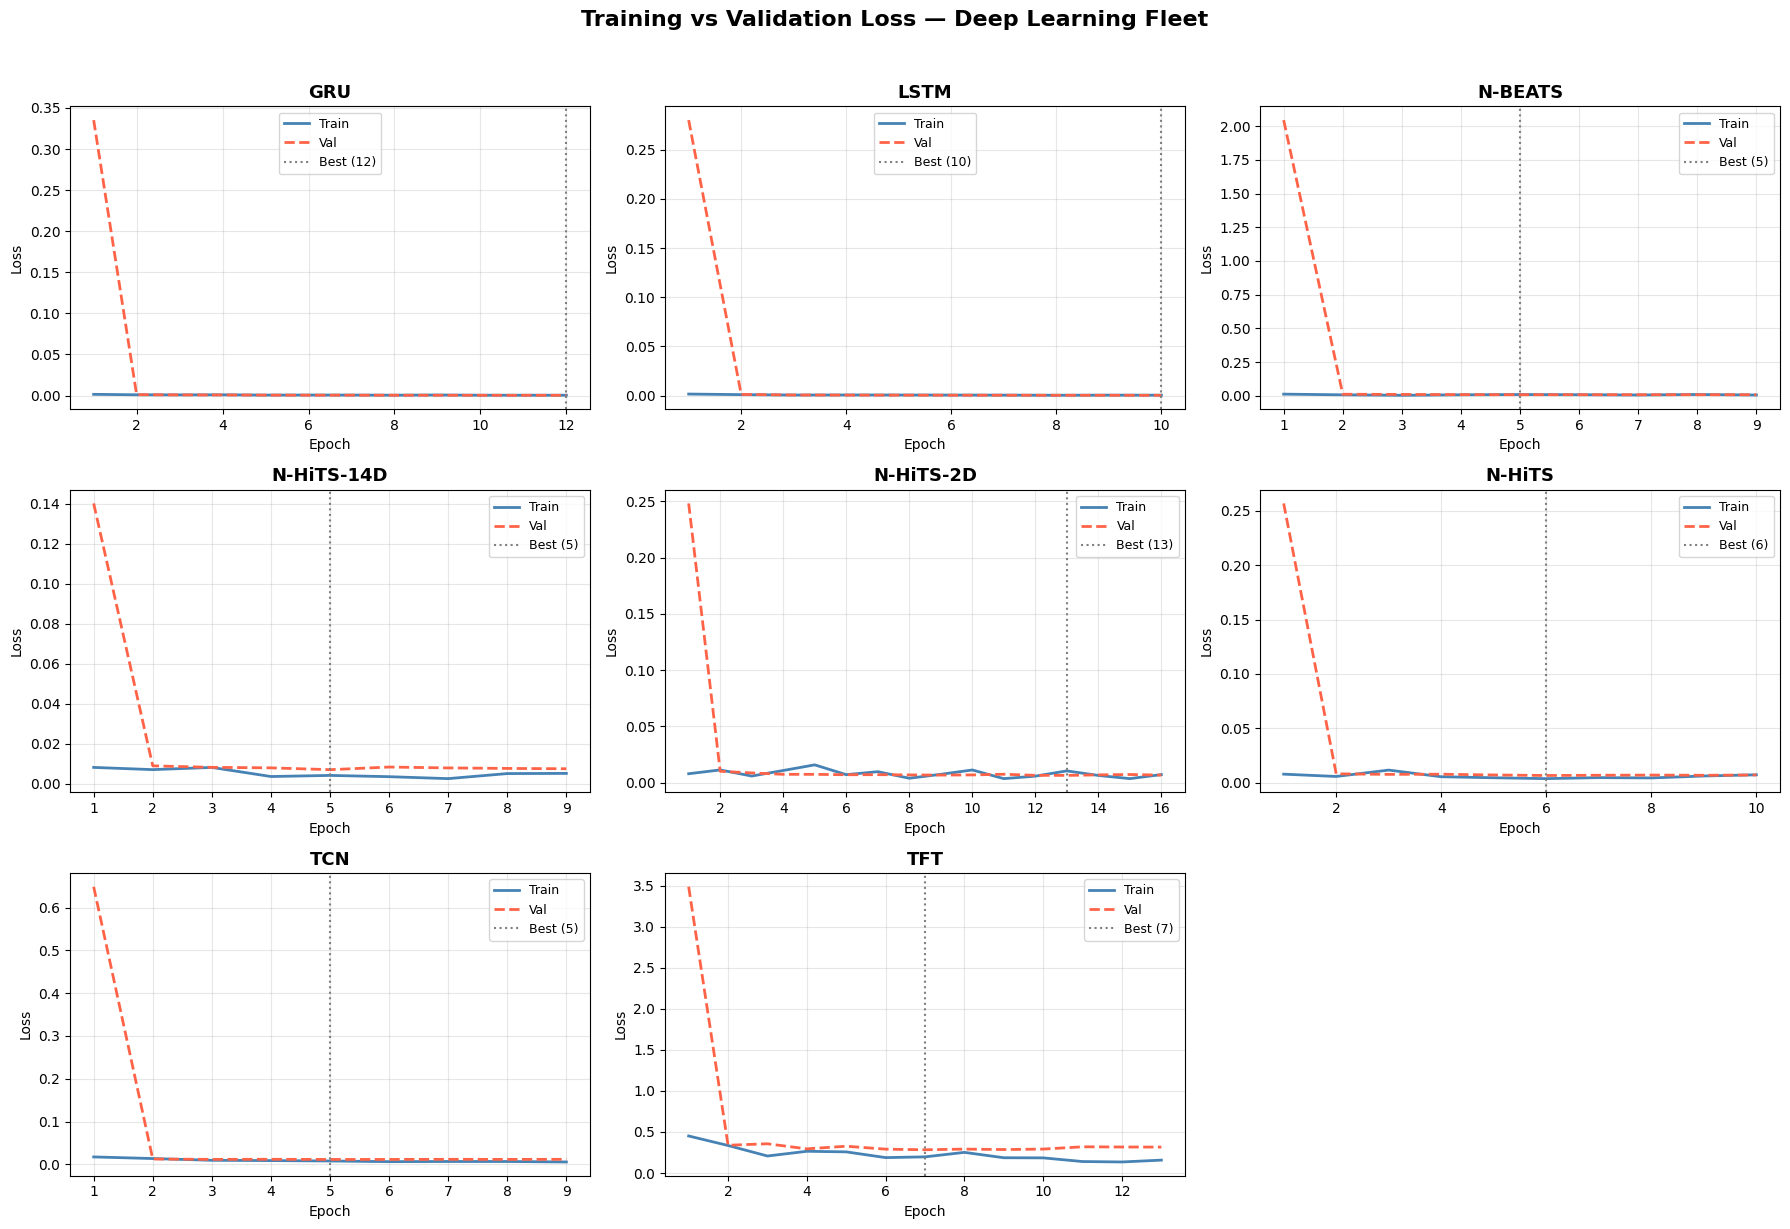

In [15]:
from modeling_dl import plot_saved_loss_curves
plot_saved_loss_curves()

### 6.2 Best Model Visualisation

Best model: N-HiTS


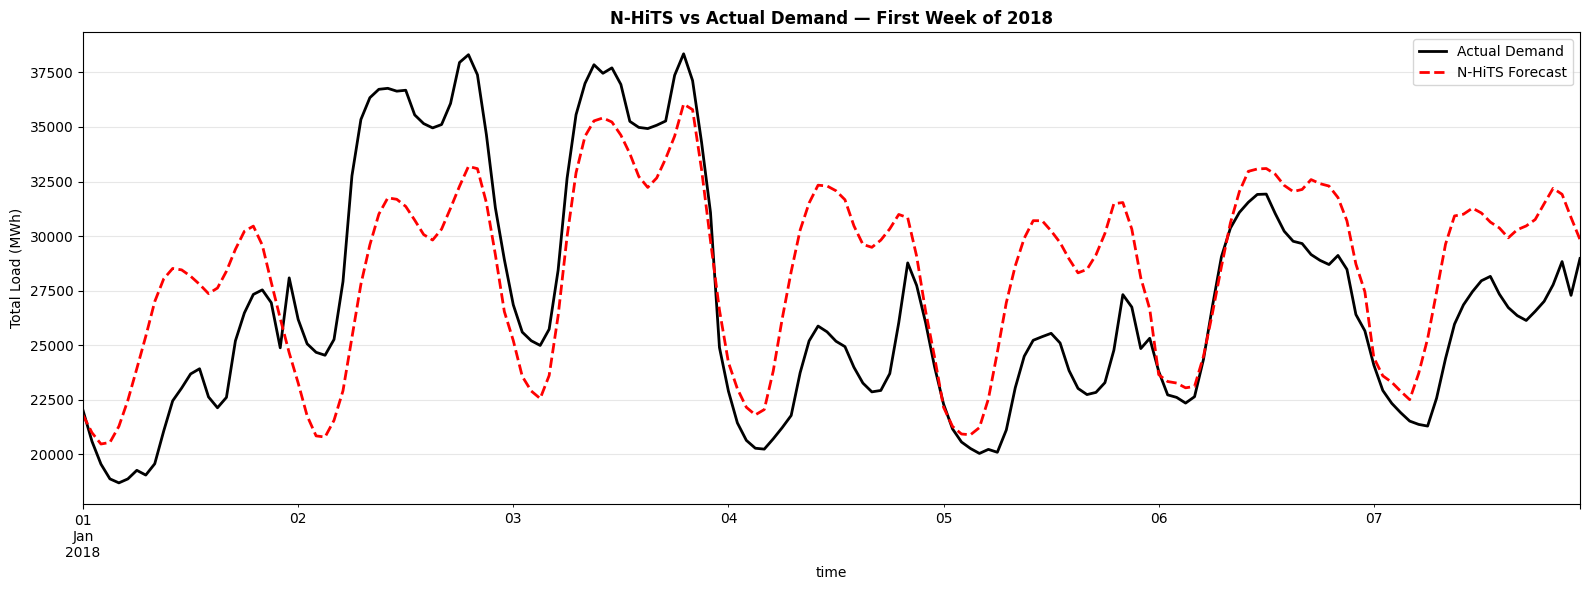

In [16]:
import matplotlib.pyplot as plt

top_name = leaderboard[0][0]
print(f"Best model: {top_name}")

actuals_ts = darts_dataset["test_target_unscaled"]

plt.figure(figsize=(16, 6))
actuals_ts[:168].plot(label="Actual Demand", color="black", linewidth=2)
predictions[top_name][:168].plot(label=f"{top_name} Forecast", color="red", linestyle="--")
plt.title(f"{top_name} vs Actual Demand — First Week of 2018", fontweight="bold")
plt.ylabel("Total Load (MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Master Comparison Table

In [21]:
# Aggregate all model results into a single leaderboard
import pandas as pd

all_results = {
    "TSO Baseline":  tso_metrics,
    "XGBoost":       xgb_metrics,
    "LightGBM":      lgbm_metrics,
    **alt_metrics,
}

# Add deep learning results
for name, metrics in leaderboard:
    all_results[f"DL: {name}"] = metrics

comparison_df = pd.DataFrame(all_results).T[["MAE", "MAPE", "RMSE"]]
comparison_df = comparison_df.sort_values("MAE")
comparison_df["vs TSO (MAE)"] = comparison_df["MAE"] - tso_metrics["MAE"]

print(comparison_df.round(2).to_string())
display(comparison_df.style
        .background_gradient(subset=["MAE"], cmap="RdYlGn_r")
        .format({"MAE": "{:,.2f}", "MAPE": "{:.3f}", "RMSE": "{:,.2f}", "vs TSO (MAE)": "{:+,.2f}"}))

                  MAE  MAPE     RMSE  vs TSO (MAE)
TSO Baseline   269.85  0.93   389.32          0.00
DL: N-HiTS    1418.94  4.83  2076.17       1149.09
LightGBM      1485.13  5.08  2339.57       1215.28
CatBoost      1488.35  5.08  2278.51       1218.50
XGBoost       1499.52  5.14  2312.00       1229.67
DL: LSTM      1548.23  5.33  2366.62       1278.38
RandomForest  1584.77  5.46  2395.38       1314.92
DL: N-BEATS   1671.61  5.56  2368.79       1401.76
DL: GRU       1685.82  5.61  2427.91       1415.97
DL: TCN       1712.52  5.94  2527.41       1442.67
MLP           1870.69  6.47  2568.02       1600.84


,MAE,MAPE,RMSE,vs TSO (MAE)
TSO Baseline,269.85,0.926,389.32,+0.00
DL: N-HiTS,"1,418.94",4.831,"2,076.17","+1,149.09"
LightGBM,"1,485.13",5.079,"2,339.57","+1,215.28"
CatBoost,"1,488.35",5.080,"2,278.51","+1,218.50"
XGBoost,"1,499.52",5.137,"2,312.00","+1,229.67"
DL: LSTM,"1,548.23",5.325,"2,366.62","+1,278.38"
RandomForest,"1,584.77",5.458,"2,395.38","+1,314.92"
DL: N-BEATS,"1,671.61",5.558,"2,368.79","+1,401.76"
DL: GRU,"1,685.82",5.615,"2,427.91","+1,415.97"
DL: TCN,"1,712.52",5.942,"2,527.41","+1,442.67"


# Ensemble Strategies

--- INICIANDO MOTOR DE ENSEMBLE: MODO COMPETICIÓN ---

                              MAE  MAPE     RMSE
TSO Baseline               269.85  0.93   389.32
ENSEMBLE: Power Blend P2  1157.35  3.94  1762.77
Ensemble: Simple Mean     1162.09  3.95  1772.47
Ensemble: v4 Optimized    1177.94  4.01  1804.75
Ensemble: Meta-Lasso      1254.70  4.25  1856.00
N-HiTS (Best Solo)        1345.99  4.57  1980.77


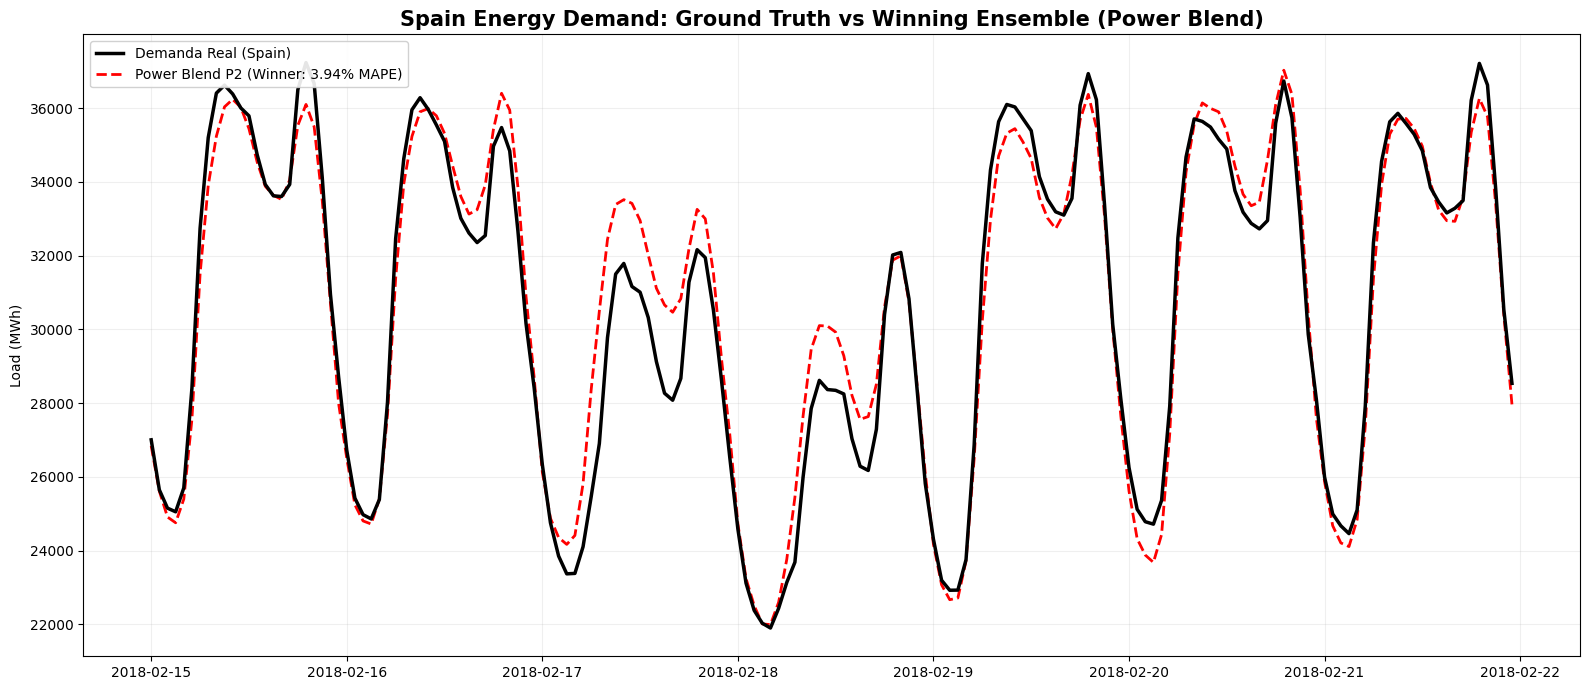


[Insights] Pesos de la Optimización v4 (para comparar con el Winner):
  > N-HiTS      :  41.4%
  > LSTM        :  50.1%
  > CatBoost    :   8.6%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.linear_model import Lasso
from scipy.optimize import minimize
import matplotlib.pyplot as plt

print("--- INICIANDO MOTOR DE ENSEMBLE: MODO COMPETICIÓN ---")

ensemble_df = pd.DataFrame(index=y_test.index)
ensemble_df['Actual'] = y_test.values

top_candidates = ['N-HiTS', 'LSTM', 'LightGBM', 'XGBoost', 'CatBoost']
for m in top_candidates:
    if m in predictions:
        df_temp = predictions[m].to_dataframe()
        if df_temp.index.tz is None and ensemble_df.index.tz is not None:
            df_temp.index = df_temp.index.tz_localize(ensemble_df.index.tz)
        ensemble_df[m] = df_temp.iloc[:, 0]
    elif m in alt_preds:
        ensemble_df[m] = alt_preds[m]

ensemble_df = ensemble_df.dropna()
model_names = [c for c in ensemble_df.columns if c != 'Actual']

train_size = 45 * 24
train_df = ensemble_df.iloc[:train_size]
eval_df  = ensemble_df.iloc[train_size:].copy()


eval_df['ENSEMBLE: Power Blend P2'] = (eval_df[model_names]**2).mean(axis=1)**(1/2)

def objective_mae(weights):
    weights = weights / np.sum(weights)
    weighted_pred = (train_df[model_names] * weights).sum(axis=1)
    return mean_absolute_error(train_df['Actual'], weighted_pred)

res_opt = minimize(objective_mae, [1./len(model_names)]*len(model_names), 
                   method='SLSQP', bounds=[(0, 1)]*len(model_names), 
                   constraints=({'type': 'eq', 'fun': lambda w: np.sum(w) - 1}))
best_w_opt = res_opt.x / np.sum(res_opt.x)
eval_df['Ensemble: v4 Optimized'] = (eval_df[model_names] * best_w_opt).sum(axis=1)

meta_lasso = Lasso(alpha=0.1, positive=True)
meta_lasso.fit(train_df[model_names], train_df['Actual'])
eval_df['Ensemble: Meta-Lasso'] = meta_lasso.predict(eval_df[model_names])

eval_df['Ensemble: Simple Mean'] = eval_df[model_names].mean(axis=1)


def get_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

leaderboard = {
    'TSO Baseline': tso_metrics,
    'ENSEMBLE: Power Blend P2': get_metrics(eval_df['Actual'], eval_df['ENSEMBLE: Power Blend P2']),
    'Ensemble: v4 Optimized': get_metrics(eval_df['Actual'], eval_df['Ensemble: v4 Optimized']),
    'Ensemble: Meta-Lasso': get_metrics(eval_df['Actual'], eval_df['Ensemble: Meta-Lasso']),
    'Ensemble: Simple Mean': get_metrics(eval_df['Actual'], eval_df['Ensemble: Simple Mean']),
    'N-HiTS (Best Solo)': get_metrics(eval_df['Actual'], eval_df['N-HiTS'])
}

report_df = pd.DataFrame(leaderboard).T[['MAE', 'MAPE', 'RMSE']].sort_values('MAE')
print("\n" + "="*95)
print(report_df.round(2).to_string())
print("="*95)

plt.figure(figsize=(16, 7))
plot_window = eval_df.iloc[:168] 

plt.plot(plot_window.index, plot_window['Actual'], label='Demanda Real (Spain)', color='black', lw=2.5, zorder=3)
plt.plot(plot_window.index, plot_window['ENSEMBLE: Power Blend P2'], 
         label='Power Blend P2 (Winner: 3.94% MAPE)', color='#FF0000', lw=2, linestyle='--')

plt.title("Spain Energy Demand: Ground Truth vs Winning Ensemble (Power Blend)", fontsize=15, fontweight='bold')
plt.ylabel("Load (MWh)")
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\n[Insights] Pesos de la Optimización v4 (para comparar con el Winner):")
for name, w in zip(model_names, best_w_opt):
    if w > 0.01:
        print(f"  > {name:<12}: {w*100:>5.1f}%")

# Error Analysis

In [41]:
# ==============================================================================
# ERROR ANALYSIS: DATA PREPARATION
# ==============================================================================
import seaborn as sns

# We focus on your winner: Power Blend P2
best_ensemble = 'ENSEMBLE: Power Blend P2'
print(f"🥇 Analyzing errors for the Champion: {best_ensemble}")

# Create analysis dataframe from eval_df
error_df = eval_df[['Actual', best_ensemble]].copy()
error_df.columns = ["Actual_Demand", "Predicted_Demand"]

# Calculate core metrics
error_df["Error"] = error_df["Predicted_Demand"] - error_df["Actual_Demand"]
error_df["Absolute_Error"] = error_df["Error"].abs()
error_df["Percentage_Error"] = (error_df["Absolute_Error"] / error_df["Actual_Demand"]) * 100

# Extract Time Metadata
error_df["Hour"] = error_df.index.hour
error_df["DayOfWeek"] = error_df.index.day_name()
error_df["Date"] = error_df.index.date
error_df["Month"] = error_df.index.month
error_df["Season"] = error_df["Month"].map({
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Spring", 4:"Spring", 5:"Spring",
    6:"Summer", 7:"Summer", 8:"Summer",
    9:"Autumn", 10:"Autumn", 11:"Autumn"
})

print(f"Data ready. Mean Bias: {error_df['Error'].mean():.2f} MWh")
error_df.head()

🥇 Analyzing errors for the Champion: ENSEMBLE: Power Blend P2
Data ready. Mean Bias: -227.31 MWh


,Actual_Demand,Predicted_Demand,Error,Absolute_Error,Percentage_Error,Hour,DayOfWeek,Date,Month,Season
time,,,,,,,,,,
2018-02-15 00:00:00+00:00,27002.0,26835.928521,-166.071479,166.071479,0.615034,0,Thursday,2018-02-15,2,Winter
2018-02-15 01:00:00+00:00,25646.0,25608.707039,-37.292961,37.292961,0.145414,1,Thursday,2018-02-15,2,Winter
2018-02-15 02:00:00+00:00,25149.0,24908.428688,-240.571312,240.571312,0.956584,2,Thursday,2018-02-15,2,Winter
2018-02-15 03:00:00+00:00,25050.0,24752.225454,-297.774546,297.774546,1.188721,3,Thursday,2018-02-15,2,Winter
2018-02-15 04:00:00+00:00,25697.0,25393.112748,-303.887252,303.887252,1.182579,4,Thursday,2018-02-15,2,Winter


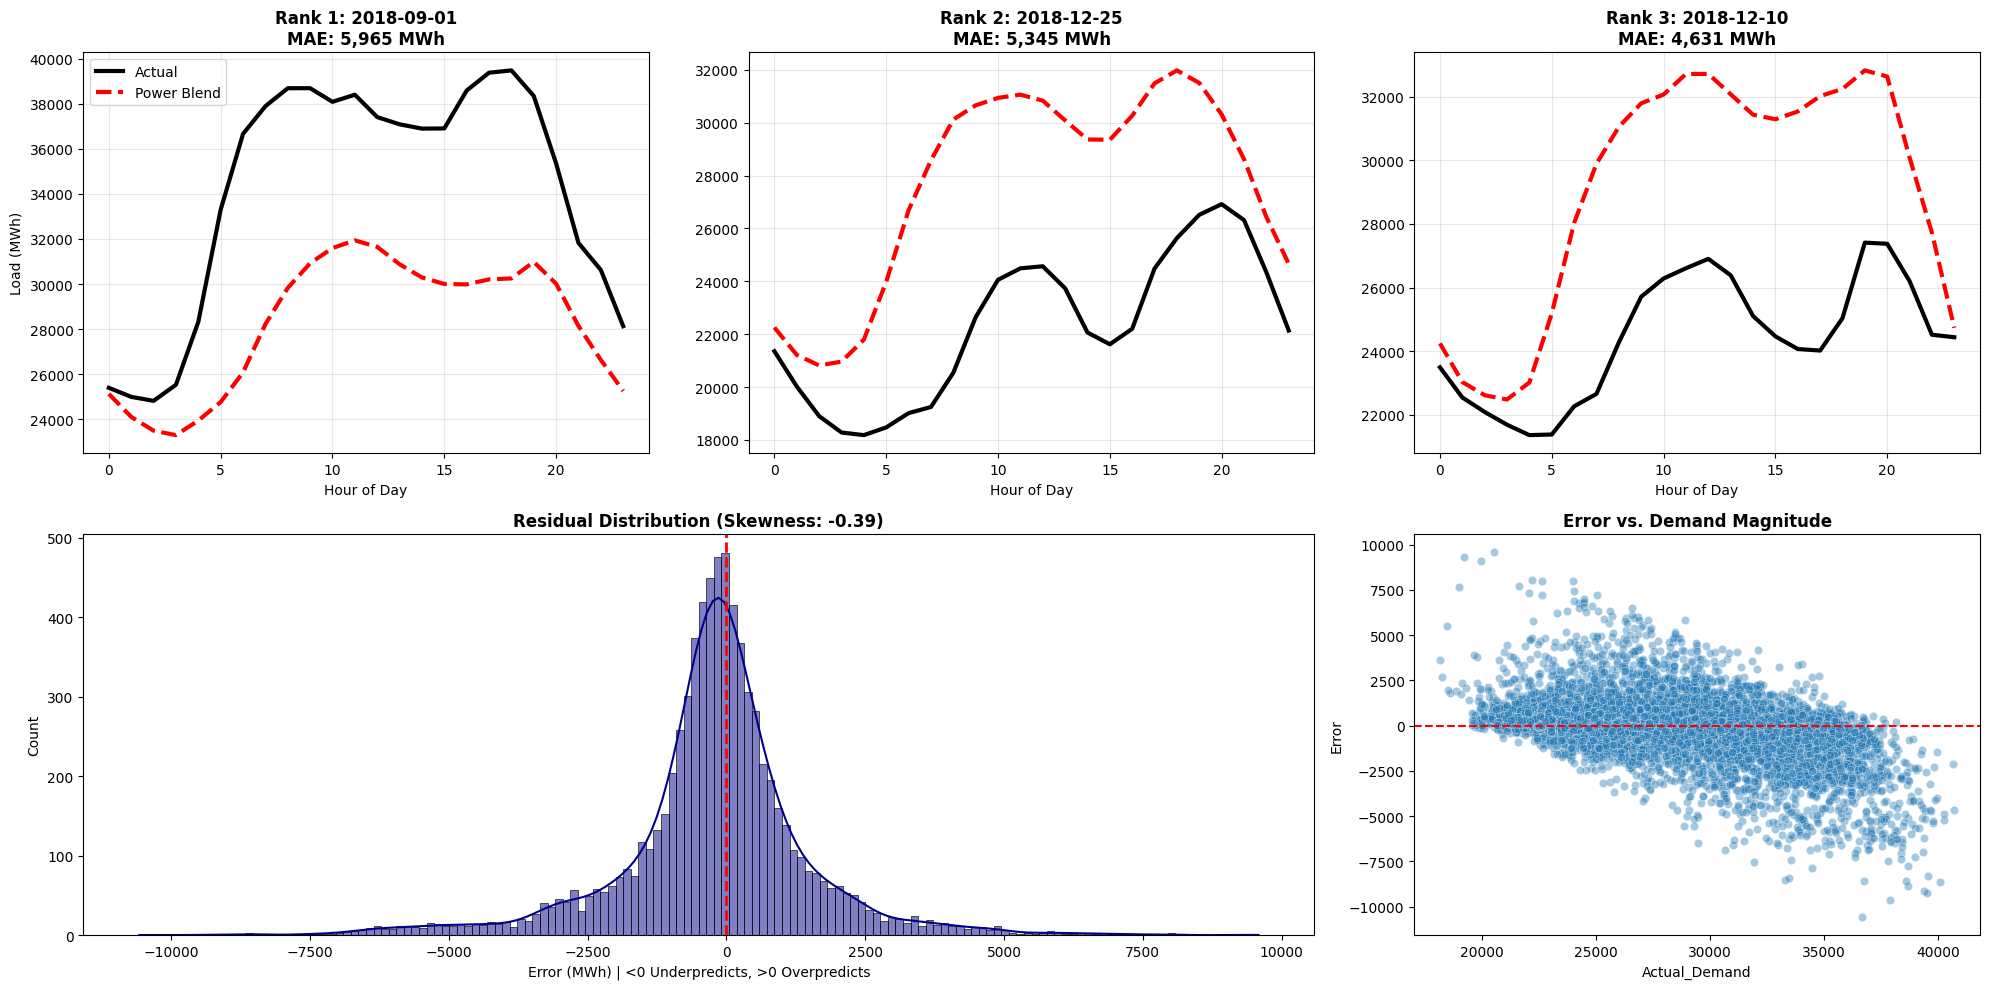

In [42]:
# ==============================================================================
# ANALYSIS 1: EXTREME ERRORS & RESIDUAL DISTRIBUTION
# ==============================================================================
fig = plt.figure(figsize=(20, 10))
gs = plt.GridSpec(2, 3, figure=fig)

# 1.1 Top 3 Worst Days
daily_mae = error_df.groupby("Date")["Absolute_Error"].mean().sort_values(ascending=False)
worst_3 = daily_mae.head(3)

for i, (date, mae_val) in enumerate(worst_3.items()):
    ax = fig.add_subplot(gs[0, i])
    day_data = error_df[error_df["Date"] == date]
    ax.plot(day_data.index.hour, day_data["Actual_Demand"], color="black", lw=3, label="Actual")
    ax.plot(day_data.index.hour, day_data["Predicted_Demand"], color="red", ls="--", lw=3, label="Power Blend")
    ax.set_title(f"Rank {i+1}: {date}\nMAE: {mae_val:,.0f} MWh", fontweight="bold")
    ax.set_xlabel("Hour of Day")
    ax.grid(True, alpha=0.3)
    if i == 0: ax.set_ylabel("Load (MWh)"); ax.legend()

# 1.2 Residual Histogram (Bias Check)
ax_hist = fig.add_subplot(gs[1, :2])
sns.histplot(error_df["Error"], kde=True, ax=ax_hist, color="darkblue")
ax_hist.axvline(0, color="red", linestyle="--", lw=2)
ax_hist.set_title(f"Residual Distribution (Skewness: {error_df['Error'].skew():.2f})", fontweight="bold")
ax_hist.set_xlabel("Error (MWh) | <0 Underpredicts, >0 Overpredicts")

# 1.3 Heteroscedasticity (Error vs Load)
ax_scatter = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=error_df, x="Actual_Demand", y="Error", alpha=0.4, ax=ax_scatter)
ax_scatter.axhline(0, color="red", ls="--")
ax_scatter.set_title("Error vs. Demand Magnitude", fontweight="bold")

plt.tight_layout()
plt.show()

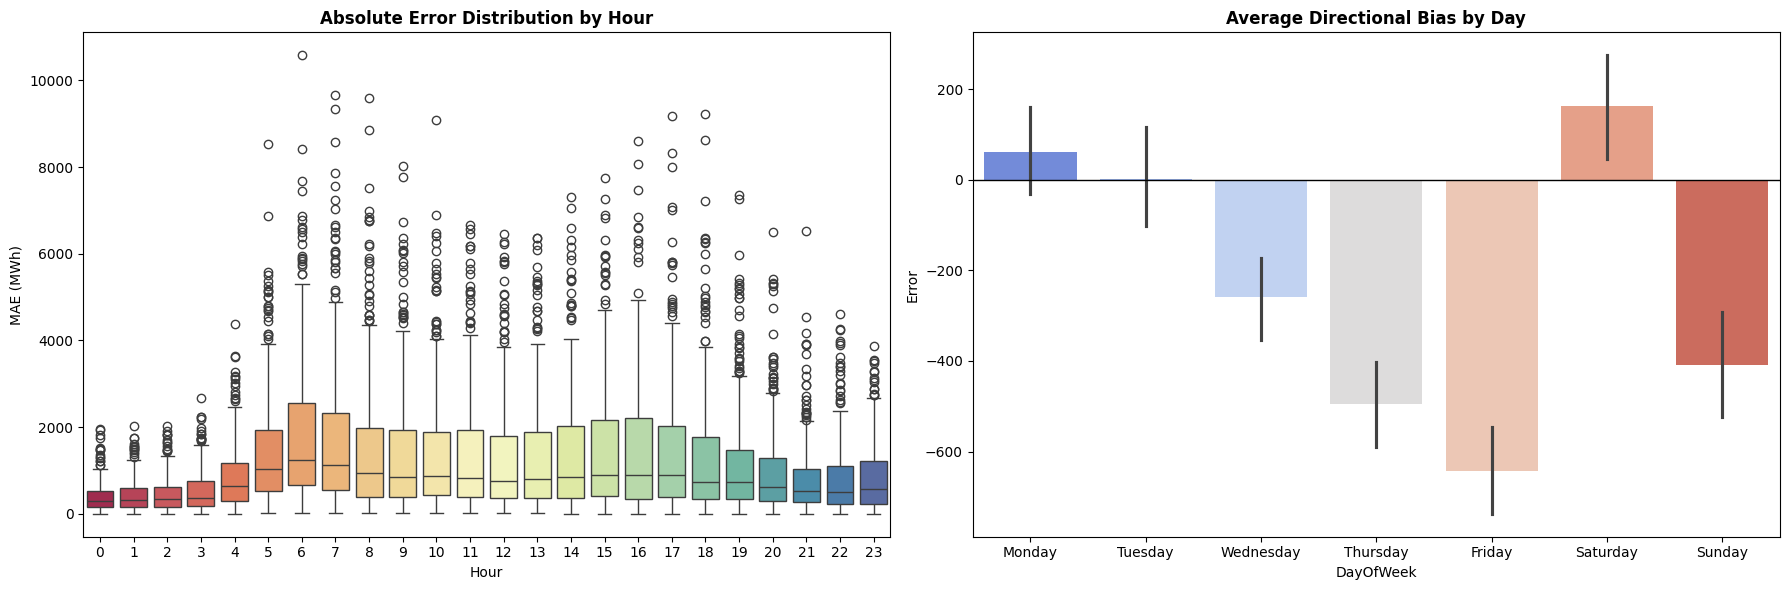

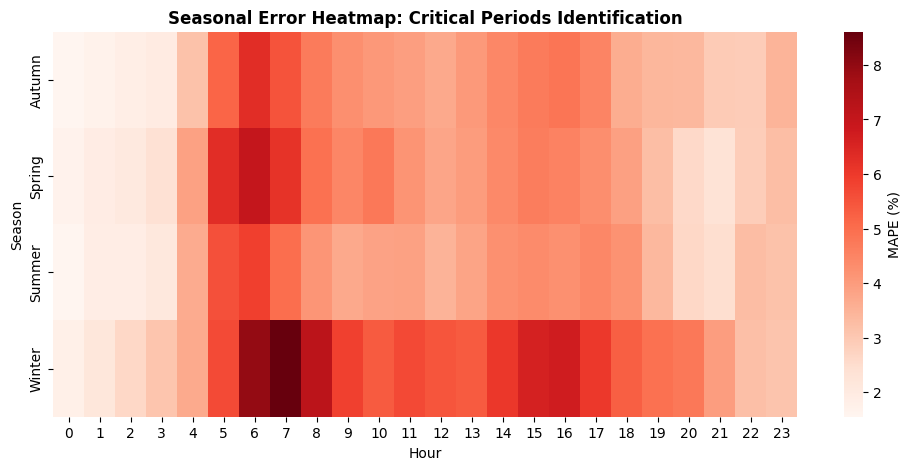

In [43]:
# ==============================================================================
# ANALYSIS 2: SYSTEMATIC TEMPORAL BIAS
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 2.1 Error by Hour (Hourly Volatility)
sns.boxplot(data=error_df, x="Hour", y="Absolute_Error", ax=axes[0], palette="Spectral")
axes[0].set_title("Absolute Error Distribution by Hour", fontweight="bold")
axes[0].set_ylabel("MAE (MWh)")

# 2.2 Directional Bias by Day of Week
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sns.barplot(data=error_df, x="DayOfWeek", y="Error", order=day_order, ax=axes[1], palette="coolwarm")
axes[1].set_title("Average Directional Bias by Day", fontweight="bold")
axes[1].axhline(0, color="black", lw=1)

plt.tight_layout()
plt.show()

# 2.3 Seasonal Heatmap (Percentage Error)
plt.figure(figsize=(12, 5))
pivot_error = error_df.pivot_table(index='Season', columns='Hour', values='Percentage_Error', aggfunc='mean')
sns.heatmap(pivot_error, cmap="Reds", annot=False, cbar_kws={'label': 'MAPE (%)'})
plt.title("Seasonal Error Heatmap: Critical Periods Identification", fontweight="bold")
plt.show()

🚀 TOP 10 FEATURES CORRELATED WITH LARGE ERRORS:
load_lag_24             0.184954
is_daylight             0.176991
load_lag_168            0.164179
is_holiday              0.159550
is_bridge_day           0.111799
load_rolling_mean_7d    0.102672
Month                   0.085163
lag_price_24            0.077095
load_std_24h            0.076210
next_day_is_holiday     0.060732
Name: Absolute_Error, dtype: float64


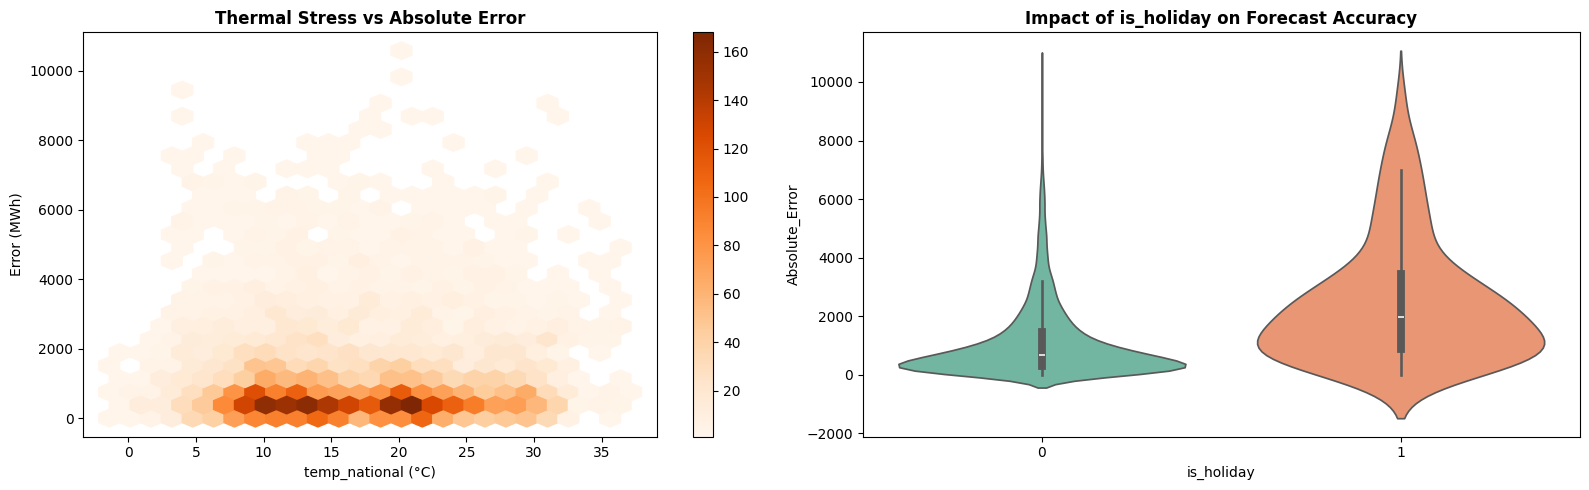

In [45]:
# ==============================================================================
# ANALYSIS 3: EXTERNAL ERROR DRIVERS (FIXED FOR TZ-ERROR)
# ==============================================================================
# 1. Clean X_test and error_df to be both TZ-NAIVE
X_analysis = X_test.copy()
error_analysis = error_df.copy()

# Force both to be naive (UTC-based but without the 'offset' info)
if X_analysis.index.tz is not None:
    X_analysis.index = X_analysis.index.tz_convert(None)

if error_analysis.index.tz is not None:
    error_analysis.index = error_analysis.index.tz_convert(None)

# 2. Perform the Join
analysis_df = error_analysis.join(X_analysis, how="inner")

# 3.1 Top Feature Correlations with Absolute Error
numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns
error_corr = (
    analysis_df[numeric_cols]
    .corr()["Absolute_Error"]
    .drop(["Error","Absolute_Error","Percentage_Error","Actual_Demand","Predicted_Demand"], errors='ignore')
    .sort_values(ascending=False)
)

print("🚀 TOP 10 FEATURES CORRELATED WITH LARGE ERRORS:")
print(error_corr.head(10))

# 3.2 Temperature Stress vs Error
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Temperature vs Error Hexbin
temp_col = 'temp_national' if 'temp_national' in analysis_df.columns else analysis_df.columns[5] # fallback
hb = ax1.hexbin(analysis_df[temp_col], analysis_df["Absolute_Error"], 
                gridsize=25, cmap="Oranges", mincnt=1)
ax1.set_title("Thermal Stress vs Absolute Error", fontweight="bold")
ax1.set_xlabel(f"{temp_col} (°C)")
ax1.set_ylabel("Error (MWh)")
fig.colorbar(hb, ax=ax1)

# Holiday Impact
# Search for holiday column dynamically
hol_col = [c for c in analysis_df.columns if "holiday" in c.lower()]
if hol_col:
    sns.violinplot(data=analysis_df, x=hol_col[0], y="Absolute_Error", ax=ax2, palette="Set2")
    ax2.set_title(f"Impact of {hol_col[0]} on Forecast Accuracy", fontweight="bold")
else:
    ax2.text(0.5, 0.5, "Holiday column not found", ha='center')

plt.tight_layout()
plt.show()